In [56]:
import pandas as pd

# Load the datasets from the specified paths
df_corona = pd.read_csv("../data cleanup/sars_cov2_cdr_seq.tsv", sep="\t")
df_human = pd.read_csv("../data cleanup/human_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("../data cleanup/influenza_cdr_seq.tsv", sep="\t")



In [57]:
#def compute_aa_composition(df, colname, group_label):
#    aac = df[colname].apply(aa_composition).apply(pd.Series)
#   aac["group"] = group_label
#   return aac



## Code für balkendiagramme für Aminosäurezusammensetzung

In [65]:
import pandas as pd

# Load the datasets from the specified paths
df_corona = pd.read_csv("../data cleanup/sars_cov2_cdr_seq.tsv", sep="\t")
df_human = pd.read_csv("../data cleanup/human_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("../data cleanup/influenza_cdr_seq.tsv", sep="\t")



In [ ]:
aa_1_to_3 = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val'
} # Mapping von 1-Buchstaben zu 3-Buchstaben Aminosäuren

# Berechnen wie oft eine Aminosäure in der jeweiligen CDRs vorkommt und in Prozent
def calculate_aa_distribution(df, column):
    aa_counts = df[column].dropna().apply(lambda x: pd.Series(list(x))).stack().value_counts() # wie oft jede AS vorkommt
    total_count = aa_counts.sum() # Totale Anzahl der Aminosäuren
    aa_distribution = (aa_counts / total_count * 100).round(2) # konvertiere in Prozent und runde auf 2 Dezimalstellen
    return aa_distribution 


import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_aa_distribution(corona, influenza, human, region_label="CDR_H3"): #definition der Funktion um die Verteilung der Aminosäuren zu plotten
    """
    Plots the grouped amino acid distribution for three datasets.
    Args:
        corona (pd.Series): Amino acid distribution for Corona.
        influenza (pd.Series): Amino acid distribution for Influenza.
        human (pd.Series): Amino acid distribution for Human.
        region_label (str): Label for the region being analyzed.
    """

    aa_order = list(aa_1_to_3.keys()) # aa_order ist eine Liste der Aminosäuren in der Reihenfolge von aa_1_to_3.keys()
    labels_3 = [aa_1_to_3[aa] for aa in aa_order] # labels_3 ist eine Liste der Aminosäuren in der 3-Buchstaben Abkürzung

    # Reindex all distributions for consistent order and fill missing with 0
    corona = corona.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Corona
    influenza = influenza.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Influenza
    human = human.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Human

    x = np.arange(len(aa_order)) # Positionen der Balken auf der x-Achse
    width = 0.25 # Breite der Balken

    # Generieren  des Balkendiagramms
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, corona.values, width, label='Corona', color='pink')
    plt.bar(x,         influenza.values, width, label='Influenza', color='mediumpurple')
    plt.bar(x + width, human.values, width, label='Human', color='skyblue')

    plt.xticks(ticks=x, labels=labels_3, rotation=45)
    plt.ylabel("Häufigkeit (%)")
    plt.xlabel("Aminosäure")
    plt.title(f"Aminosäureverteilung in {region_label}")
    plt.ylim(0, 25)  
    plt.legend()
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()


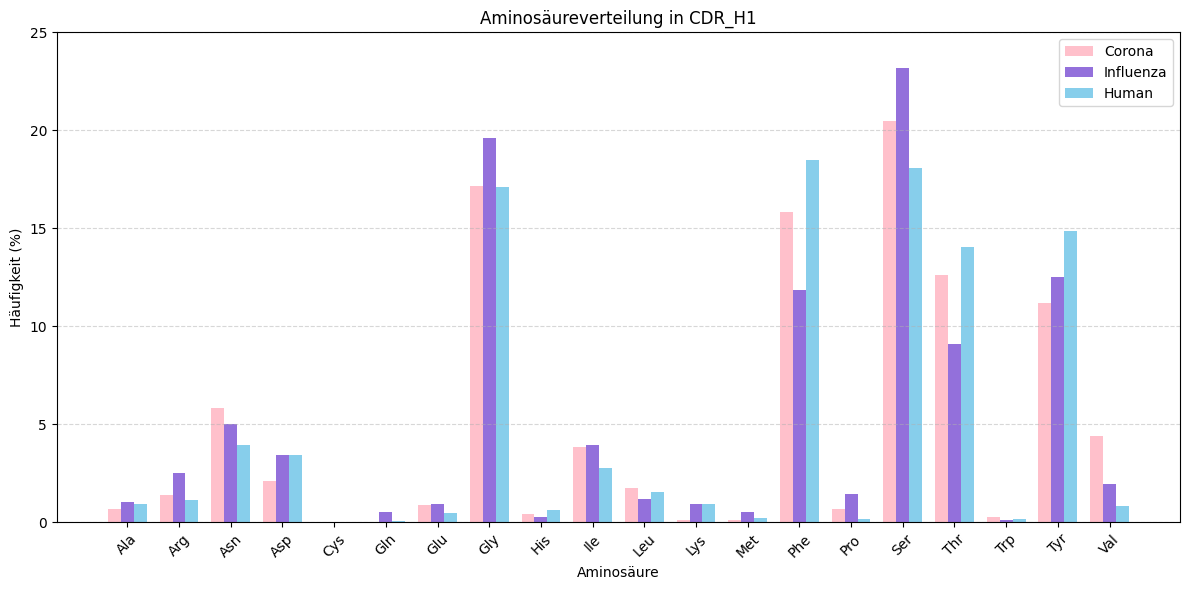

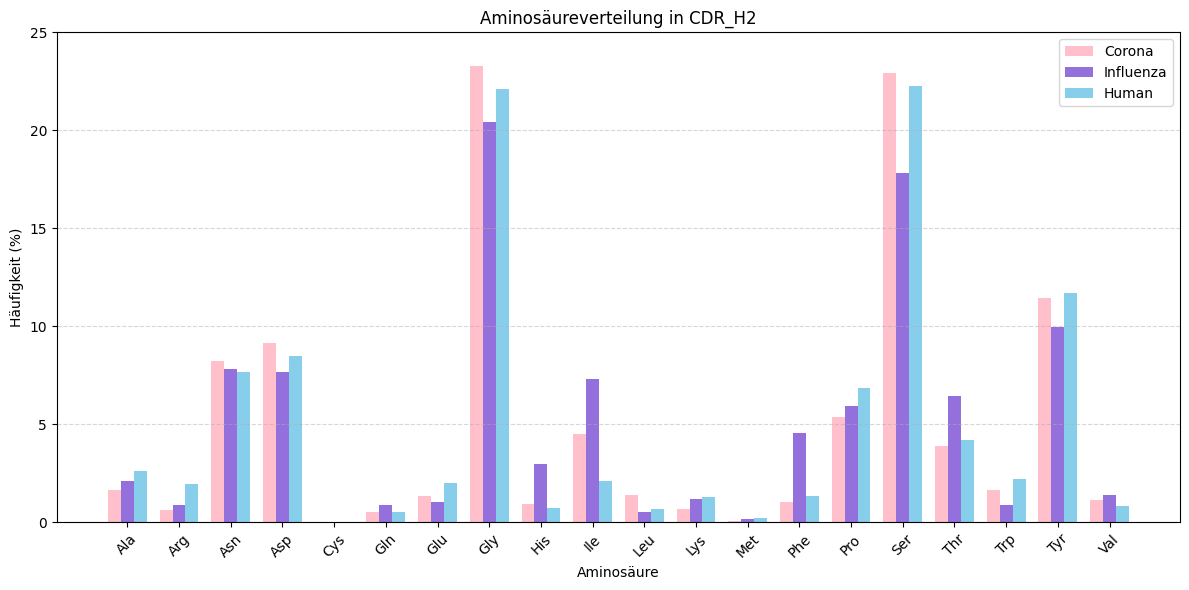

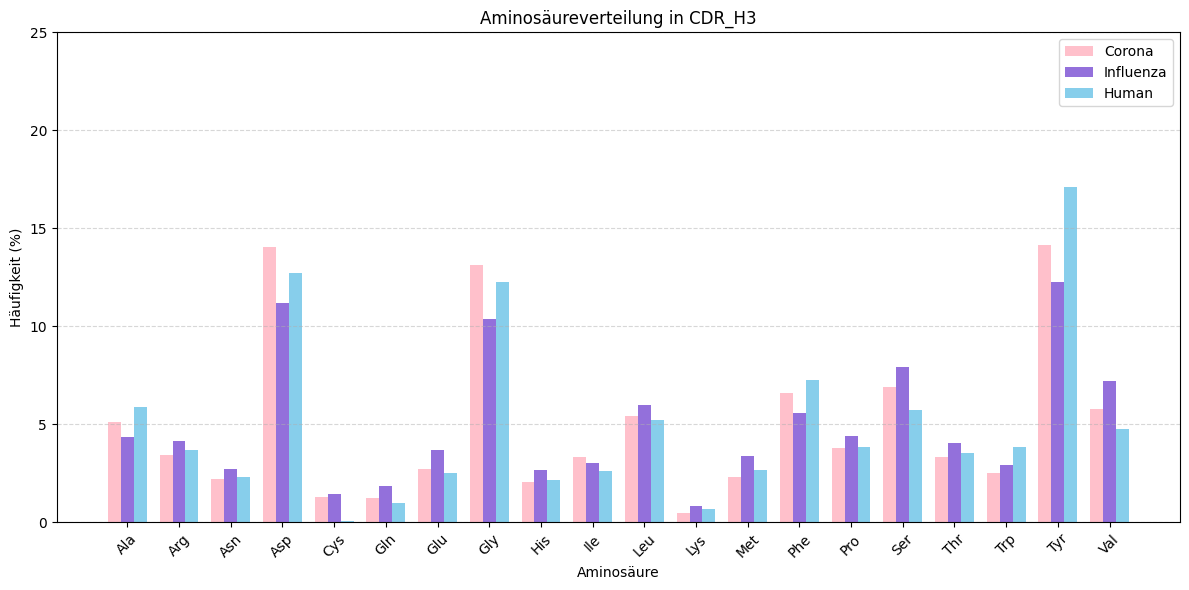

In [ ]:
for region in ["CDR_H1", "CDR_H2", "CDR_H3"]: # für jede Region in der Liste "region" wird die Funktion plot_grouped_aa_distribution aufgerufen
    plot_grouped_aa_distribution(
        calculate_aa_distribution(df_corona, region), # Berechnung der Aminosäureverteilung für Corona
        calculate_aa_distribution(df_influenza, region), # Berechnung der Aminosäureverteilung für Influenza
        calculate_aa_distribution(df_human, region), # Berechnung der Aminosäureverteilung für Human
        region_label=region
    )


## Man-Withney-U-Test

In [ ]:
def compute_aa_frequencies(df, colname, group_label): #berechnet die relative Häufigkeit der Aminosäuren in der angegebenen Spalte
    def rel_freq(seq):
        counts = pd.Series(list(seq)).value_counts() #zähle wie oft jede Aminosäure vorkommt
        total = len(seq) #berechne die Gesamtlänge der Sequenz
        return counts / total if total > 0 else pd.Series(dtype=float) #rückgabe der relativen Häufigkeit der Aminosäuren, wenn die Gesamtlänge größer als 0 ist, sonst eine leere Serie

    aa_df = df[colname].dropna().apply(rel_freq).fillna(0) #spalte colname wird auf NaN-Werte überprüft und die relative Häufigkeit der Aminosäuren wird berechnet
    aa_df["group"] = group_label # füge eine neue Spalte "group" hinzu, die den Gruppennamen enthält
    return aa_df

corona_aa = compute_aa_frequencies(df_corona, "CDR_H3", "Corona") 
influenza_aa = compute_aa_frequencies(df_influenza, "CDR_H3", "Influenza")
human_aa = compute_aa_frequencies(df_human, "CDR_H3", "Human")

all_aa = pd.concat([corona_aa, influenza_aa, human_aa], ignore_index=True).fillna(0) # Kombiniere alle Aminosäureverteilungen in einem DataFrame

all_aa

In [82]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def mann_whitney_comparison(df1, df2, aa_list, label1="Group1", label2="Group2"):
    results = []
    for aa in aa_list:
        group1 = df1[aa] if aa in df1 else pd.Series([0]*len(df1))
        group2 = df2[aa] if aa in df2 else pd.Series([0]*len(df2))
        stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
        results.append((aa, aa_1_to_3[aa], group1.mean(), group2.mean(), p))
    df_result = pd.DataFrame(results, columns=["AA", "AA_3", f"Mean_{label1}", f"Mean_{label2}", "p_value"])
    df_result["adjusted_p"] = multipletests(df_result["p_value"], method="fdr_bh")[1]
    return df_result.sort_values("adjusted_p")


In [89]:
all_results = {}

for region in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f" Vergleich für {region}...")

    # Frequenzen berechnen
    corona = compute_aa_frequencies(df_corona, region, "Corona")
    influenza = compute_aa_frequencies(df_influenza, region, "Influenza")
    human = compute_aa_frequencies(df_human, region, "Human")

    aa_list = list(aa_1_to_3.keys())

    # Paarvergleiche
    result_ci = mann_whitney_comparison(corona, influenza, aa_list, "Corona", "Influenza")
    result_ch = mann_whitney_comparison(corona, human, aa_list, "Corona", "Human")
    result_ih = mann_whitney_comparison(influenza, human, aa_list, "Influenza", "Human")

    # Speichern
    all_results[f"{region}_Corona_vs_Influenza"] = result_ci
    all_results[f"{region}_Corona_vs_Human"] = result_ch
    all_results[f"{region}_Influenza_vs_Human"] = result_ih

for name, df in all_results.items():
    print(f"\n🔎 {name}")
    print(df[["AA_3", f"Mean_{name.split('_vs_')[0].split('_')[-1]}", f"Mean_{name.split('_vs_')[-1]}", "adjusted_p"]].head(5))



 Vergleich für CDR_H1...
 Vergleich für CDR_H2...
 Vergleich für CDR_H3...

🔎 CDR_H1_Corona_vs_Influenza
   AA_3  Mean_Corona  Mean_Influenza  adjusted_p
16  Thr     0.127739        0.094484    0.001102
11  Lys     0.000966        0.009603    0.001273
19  Val     0.043986        0.017302    0.001273
5   Gln     0.000378        0.005536    0.005631
13  Phe     0.160703        0.125754    0.013181

🔎 CDR_H1_Corona_vs_Human
   AA_3  Mean_Corona  Mean_Human    adjusted_p
19  Val     0.043986    0.007701  1.245331e-16
18  Tyr     0.113909    0.150270  4.017810e-06
11  Lys     0.000966    0.009800  2.845861e-05
2   Asn     0.058443    0.040101  1.202624e-03
13  Phe     0.160703    0.188733  1.202624e-03

🔎 CDR_H1_Influenza_vs_Human
   AA_3  Mean_Influenza  Mean_Human  adjusted_p
13  Phe        0.125754    0.188733    0.000003
14  Pro        0.015714    0.001717    0.000015
16  Thr        0.094484    0.142627    0.000016
1   Arg        0.026190    0.011282    0.005333
7   Gly        0.194702 

In [ ]:
all_dfs = [] 
for name, df in all_results.items():
    region, comparison = name.split("_", 1)
    df = df.copy()
    df["region"] = region
    df["comparison"] = comparison
    all_dfs.append(df)

df_combined = pd.concat(all_dfs, ignore_index=True)
df_combined = df_combined[["region", "comparison", "AA_3", "Mean_Corona", "Mean_Influenza", "Mean_Human", "p_value", "adjusted_p"]]

df_combined




In [95]:
# Leeres Dictionary für Heatmap-Daten
heatmap_data = {}

# Schleife über alle gespeicherten Ergebnisse
for name, df in all_results.items():
    row_label = name.replace("_", ": ").replace("CDR", "CDR-")  # schöner formatieren
    row = {aa_1_to_3[aa]: -np.log10(p) if p > 0 else 10 for aa, p in zip(df["AA"], df["adjusted_p"])}
    heatmap_data[row_label] = row

import pandas as pd
import numpy as np

df_heatmap = pd.DataFrame.from_dict(heatmap_data, orient="index").fillna(0)



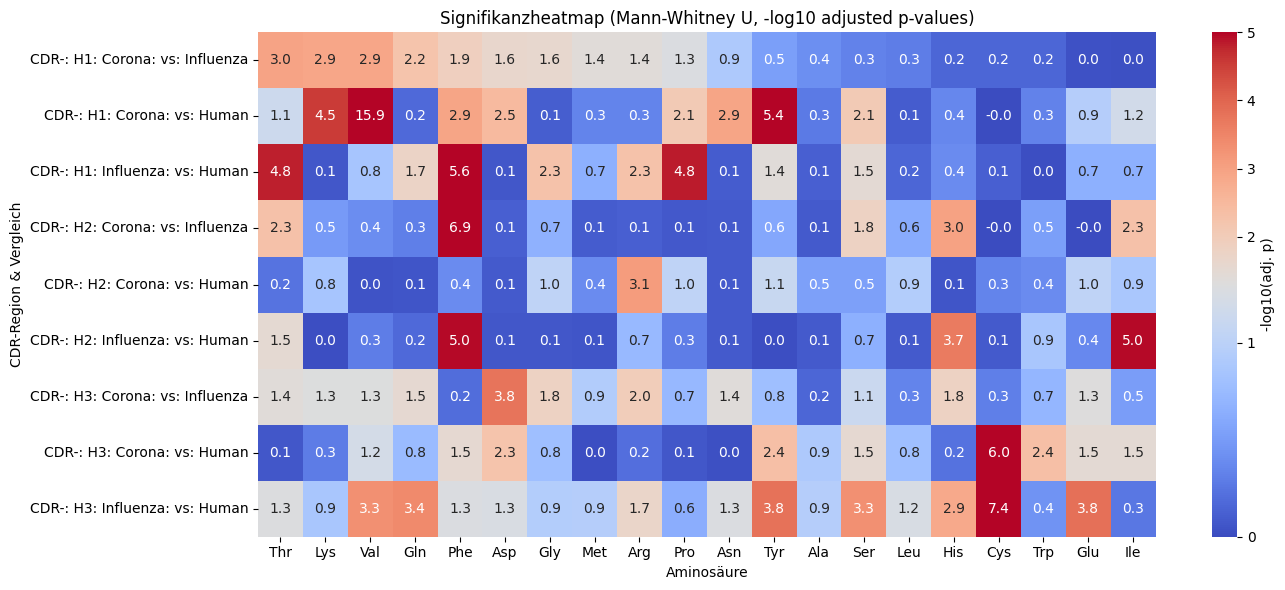

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Normierung der Farbskala: Mitte = 1.3
norm = TwoSlopeNorm(vmin=0, vcenter=1.3, vmax=5)

plt.figure(figsize=(14, 6))
sns.heatmap(
    df_heatmap,
    cmap="coolwarm",          # blau–weiß–rot-Verlauf
    annot=True,
    fmt=".1f",
    cbar_kws={'label': '-log10(adj. p)'},
    norm=norm                 # kritischer Punkt bei 1.3
)

plt.title("Signifikanzheatmap (Mann-Whitney U, -log10 adjusted p-values)")
plt.xlabel("Aminosäure")
plt.ylabel("CDR-Region & Vergleich")
plt.tight_layout()
plt.show()



 Generating plot for CDR_H1...


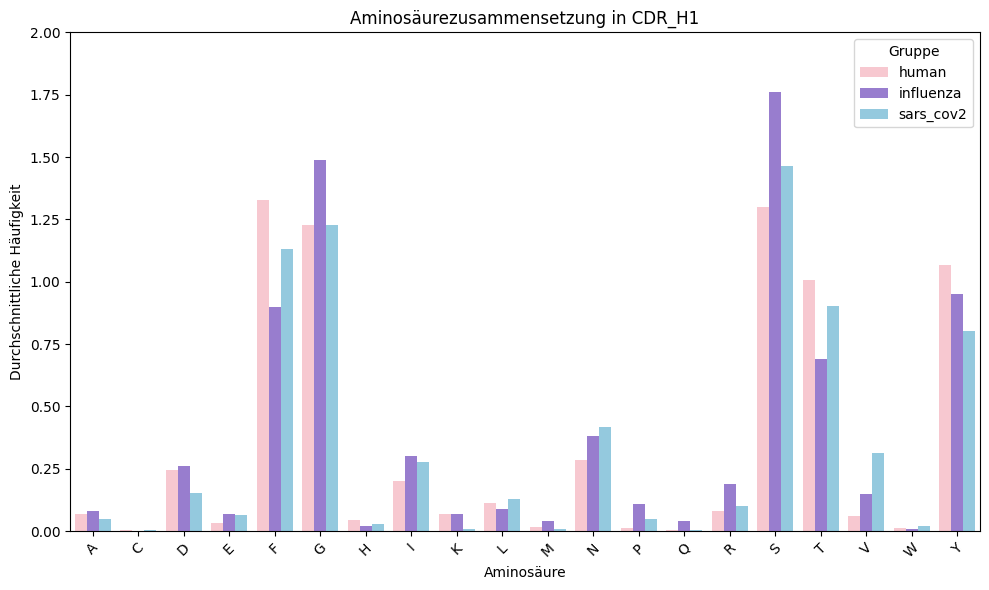


 Generating plot for CDR_H2...


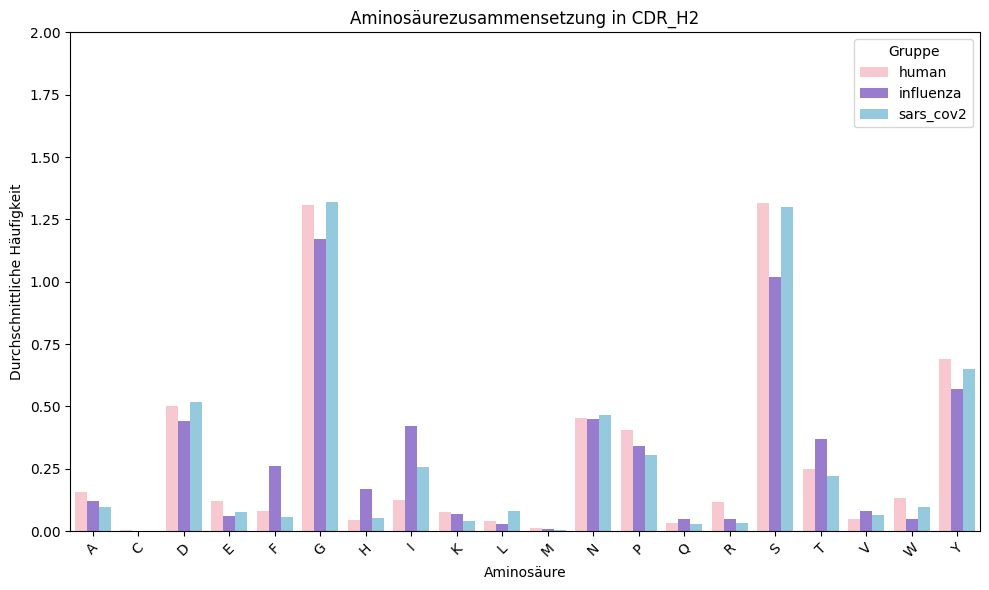


 Generating plot for CDR_H3...


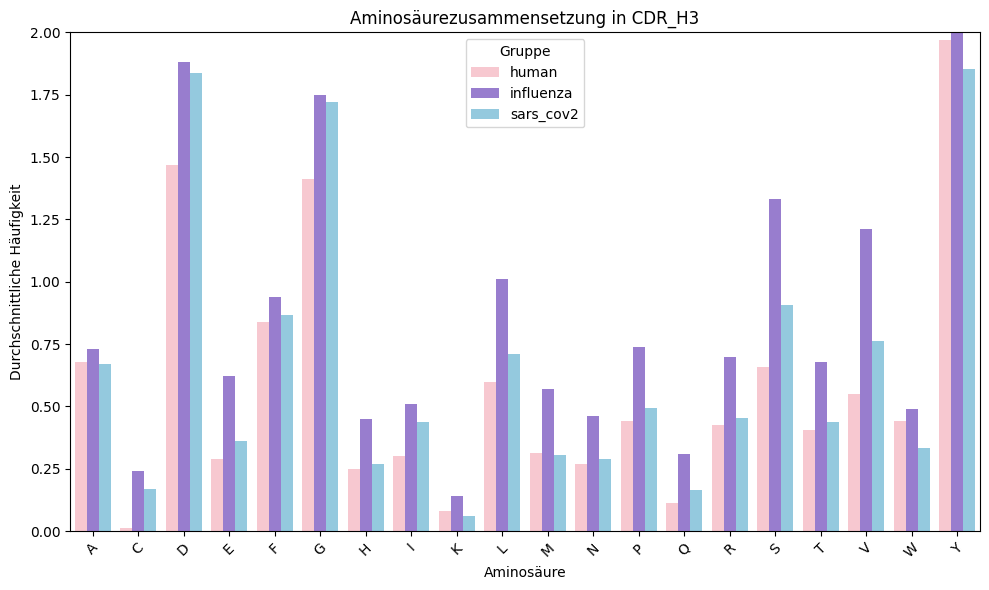

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the combined dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# List of amino acids
amino_acids = [
    "A", "R", "N", "D", "C", "Q", "E", "G", "H", "I",
    "L", "K", "M", "F", "P", "S", "T", "W", "Y", "V"
]

# Loop over all CDR regions
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f"\n Generating plot for {cdr}...")

    # Prepare data for plotting
    count_cols = [f"{cdr}_count_{aa}" for aa in amino_acids]
    plot_df = df[["source"] + count_cols]
    plot_df = plot_df.melt(id_vars="source", var_name="AminoAcid", value_name="Count")
    plot_df["AminoAcid"] = plot_df["AminoAcid"].str.replace(f"{cdr}_count_", "")

    # Calculate mean frequency per group and amino acid
    mean_df = plot_df.groupby(["source", "AminoAcid"])["Count"].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=mean_df, x="AminoAcid", y="Count", hue="source", palette=["pink", "mediumpurple", "skyblue"])
    plt.title(f"Aminosäurezusammensetzung in {cdr}")    
    plt.xlabel("Aminosäure")
    plt.ylabel("Durchschnittliche Häufigkeit")
    plt.ylim(0, 2)  # Fixiere Y-Achse auf Bereich 0 bis 0.25
    plt.legend(title="Gruppe")  
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    


C:\Users\082mi\AppData\Local\Temp\ipykernel_32424\2022203506.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lengths, x="group", y="length", palette=["pink", "mediumpurple", "skyblue"])


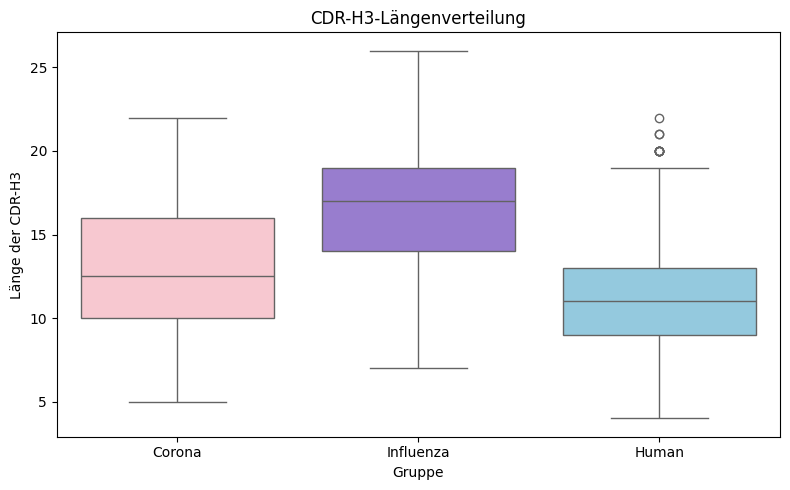

In [ ]:
import pandas as pd
# Load the datasets


df_corona["length"] = df_corona["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_corona["group"] = "Corona"

df_influenza["length"] = df_influenza["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_influenza["group"] = "Influenza"

df_human["length"] = df_human["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_human["group"] = "Human"

df_lengths = pd.concat([df_corona, df_influenza, df_human], ignore_index=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_lengths, x="group", y="length", palette=["pink", "mediumpurple", "skyblue"])
plt.title("CDR-H3-Längenverteilung")
plt.ylabel("Länge der CDR-H3")
plt.xlabel("Gruppe")
plt.tight_layout()
plt.show()



In [ ]:
def compute_zscore_df(aac_df):
    df = aac_df.drop(columns="group")
    mean = df.mean()
    std = df.std()
    z_df = (df - mean) / std
    z_df["group"] = aac_df["group"].values
    return z_df


In [73]:
# Z-Score normalisieren
z_sars_h3 = compute_zscore_df(aac_sars_h3)
z_influenza_h3 = compute_zscore_df(aac_influenza_h3)
z_human_h3 = compute_zscore_df(aac_human_h3)

# Plotten mit Z-Scores
plot_aa_composition(z_sars_h3, z_influenza_h3, z_human_h3, region_label="CDR-H3 (Z-Score)")


NameError: name 'compute_zscore_df' is not defined

In [71]:
#%pip install statsmodels

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def test_pairwise_aa_composition(aac1, aac2, label1="Corona", label2="Influenza"):
    aa_columns = [col for col in aac1.columns if col != "group"]
    results = []

    for aa in aa_columns:
        group1_vals = aac1[aa]
        group2_vals = aac2[aa]

        stat, p = mannwhitneyu(group1_vals, group2_vals, alternative="two-sided")
        results.append({
            "AminoAcid": aa,
            f"Mean_{label1}": group1_vals.mean(),
            f"Mean_{label2}": group2_vals.mean(),
            "p_value": p
        })

    df_result = pd.DataFrame(results).sort_values("p_value")
    df_result["adjusted_p"] = multipletests(df_result["p_value"], method="fdr_bh")[1]
    return df_result

results_pairwise = test_pairwise_aa_composition(aac_sars_h3, aac_influenza_h3, "Corona", "Influenza")
print(results_pairwise)


   AminoAcid  Mean_Corona  Mean_Influenza  p_value  adjusted_p
0          T     0.089589        0.077264      NaN         NaN
1          F     0.105568        0.093804      NaN         NaN
2          G     0.148948        0.127337      NaN         NaN
3          Y     0.174963        0.141268      NaN         NaN
4          D     0.153201        0.117186      NaN         NaN
5          N     0.077546        0.070478      NaN         NaN
6          E     0.086807        0.070793      NaN         NaN
7          W     0.079085        0.066693      NaN         NaN
8          L     0.109374        0.094125      NaN         NaN
9          P     0.089857        0.085447      NaN         NaN
10         R     0.092519        0.072129      NaN         NaN
11         I     0.091647        0.103265      NaN         NaN
12         H     0.085944        0.071613      NaN         NaN
13         S     0.114617        0.105453      NaN         NaN
14         A     0.109092        0.082999      NaN     

In [72]:
results_pairwise = test_pairwise_aa_composition(aac_sars_h2, aac_influenza_h2, "Corona", "Influenza")
print(results_pairwise)

   AminoAcid  Mean_Corona  Mean_Influenza  p_value  adjusted_p
0          Y     0.202657        0.219225      NaN         NaN
1          G     0.272748        0.228022      NaN         NaN
2          D     0.244724        0.213333      NaN         NaN
3          S     0.288155        0.270167      NaN         NaN
4          T     0.203404        0.168018      NaN         NaN
5          I     0.312908        0.251190      NaN         NaN
6          P     0.172754        0.166667      NaN         NaN
7          F     0.171212        0.182667      NaN         NaN
8          L     0.157778        0.166667      NaN         NaN
9          V     0.229167        0.169792      NaN         NaN
10         N     0.218199        0.221296      NaN         NaN
11         R     0.172527        0.153571      NaN         NaN
12         A     0.186429        0.181818      NaN         NaN
13         W     0.178968        0.160238      NaN         NaN
14         H     0.212963        0.206250      NaN     

In [ ]:
results_pairwise = test_pairwise_aa_composition(aac_sars_h1, aac_influenza_h1, "Corona", "Influenza")
print(results_pairwise)

   AminoAcid  Mean_Corona  Mean_Influenza   p_value  adjusted_p
16         T     0.127739        0.094484  0.000055    0.001102
11         K     0.000966        0.009603  0.000156    0.001273
19         V     0.043986        0.017302  0.000191    0.001273
5          Q     0.000378        0.005536  0.001126    0.005631
13         F     0.160703        0.125754  0.003295    0.013181
3          D     0.020770        0.033651  0.006985    0.023285
7          G     0.170818        0.194702  0.008731    0.024944
1          R     0.014193        0.026190  0.016615    0.040045
12         M     0.001050        0.005079  0.018020    0.040045
14         P     0.006965        0.015714  0.026518    0.053036
2          N     0.058443        0.051944  0.068782    0.125058
18         Y     0.113909        0.127599  0.179279    0.298799
0          A     0.006713        0.010794  0.249759    0.384245
15         S     0.202144        0.222083  0.328920    0.469885
10         L     0.017049        0.01011

In [70]:
results_pairwise = test_pairwise_aa_composition(aac_sars_h3, aac_human_h3, "Corona", "Influenza")
print(results_pairwise)

   AminoAcid  Mean_Corona  Mean_Influenza  p_value  adjusted_p
0          T     0.089589        0.112757      NaN         NaN
1          F     0.105568        0.124553      NaN         NaN
2          G     0.148948        0.151341      NaN         NaN
3          Y     0.174963        0.195790      NaN         NaN
4          D     0.153201        0.143265      NaN         NaN
5          N     0.077546        0.106460      NaN         NaN
6          E     0.086807        0.096713      NaN         NaN
7          W     0.079085        0.102106      NaN         NaN
8          L     0.109374        0.117957      NaN         NaN
9          P     0.089857        0.103253      NaN         NaN
10         R     0.092519        0.108944      NaN         NaN
11         I     0.091647        0.102358      NaN         NaN
12         H     0.085944        0.099799      NaN         NaN
13         S     0.114617        0.125563      NaN         NaN
14         A     0.109092        0.123314      NaN     

In [ ]:
results_pairwise = test_pairwise_aa_composition(aac_sars_h2, aac_human_h2, "Corona", "Influenza")
print(results_pairwise)

   AminoAcid  Mean_Corona  Mean_Influenza   p_value  adjusted_p
1          R     0.005933        0.018878  0.000039    0.000789
18         Y     0.120093        0.117018  0.007821    0.078210
6          E     0.012676        0.019635  0.020448    0.092854
7          G     0.240278        0.222198  0.020595    0.092854
14         P     0.052557        0.067898  0.023214    0.092854
10         L     0.012522        0.007036  0.034746    0.115819
9          I     0.042218        0.020822  0.047228    0.134938
11         K     0.006507        0.011556  0.056610    0.141524
15         S     0.229456        0.224340  0.143713    0.292767
0          A     0.017262        0.026278  0.146384    0.292767
12         M     0.000882        0.002199  0.256833    0.403248
13         F     0.009965        0.013482  0.258374    0.403248
17         W     0.017045        0.023407  0.262111    0.403248
4          C     0.000000        0.000440  0.319232    0.456045
16         T     0.038205        0.04188

In [ ]:
results_pairwise = test_pairwise_aa_composition(aac_human_h2, aac_human_h3, "Corona", "Influenza")
print(results_pairwise)

   AminoAcid  Mean_Corona  Mean_Influenza       p_value    adjusted_p
13         F     0.013482        0.078215  3.536694e-47  7.073387e-46
15         S     0.224340        0.054664  1.533937e-43  1.533937e-42
19         V     0.008534        0.047487  1.802870e-33  1.103597e-32
10         L     0.007036        0.050731  2.207193e-33  1.103597e-32
7          G     0.222198        0.125386  7.103828e-26  2.841531e-25
12         M     0.002199        0.026358  5.681636e-25  1.893879e-24
0          A     0.026278        0.059542  3.866347e-20  1.104671e-19
3          D     0.086456        0.130791  7.335567e-19  1.833892e-18
18         Y     0.117018        0.168410  6.648334e-12  1.477408e-11
17         W     0.023407        0.038795  9.426278e-12  1.885256e-11
1          R     0.018878        0.035931  4.235510e-10  7.700928e-10
8          H     0.008004        0.020013  5.484726e-10  9.141210e-10
2          N     0.074764        0.024157  1.173759e-08  1.805783e-08
9          I     0.0

## AAC nach Gruppen

In [ ]:
aa_properties = {
    'A': 'unpolar',  # Ala
    'V': 'unpolar',  # Val
    'L': 'unpolar',  # Leu
    'I': 'unpolar',  # Ile
    'M': 'unpolar',  # Met
    'F': 'aromatisch',  # Phe
    'W': 'aromatisch',  # Trp
    'P': 'unpolar',  # Pro
    'G': 'unpolar',  # Gly
    'C': 'polar',    # Cys (schwach polar)

    'S': 'polar',    # Ser
    'T': 'polar',    # Thr
    'N': 'polar',    # Asn
    'Q': 'polar',    # Gln
    'Y': 'aromatisch',  # Tyr (polar, aber aromatisch)

    'K': 'basisch',  # Lys
    'R': 'basisch',  # Arg
    'H': 'basisch',  # His

    'D': 'sauer',    # Asp
    'E': 'sauer'     # Glu
}

def group_by_property(row):
    grouped = {'unpolar': 0, 'polar': 0, 'sauer': 0, 'basisch': 0, 'aromatisch': 0}
    for aa, freq in row.items():
        if aa in aa_properties:
            prop = aa_properties[aa]
            grouped[prop] += freq
    return pd.Series(grouped)


# Group by properties for CDR-H3
aac_sars_props_h3 = aac_sars_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h3["group"] = "Corona"
aac_influenza_props_h3 = aac_influenza_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h3["group"] = "Influenza"
aac_human_props_h3 = aac_human_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h3["group"] = "Human"

# Group by properties for CDR-H2
aac_sars_props_h2 = aac_sars_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h2["group"] = "Corona"    
aac_influenza_props_h2 = aac_influenza_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h2["group"] = "Influenza"
aac_human_props_h2 = aac_human_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h2["group"] = "Human"

# Group by properties for CDR-H1
aac_sars_props_h1 = aac_sars_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h1["group"] = "Corona"       
aac_influenza_props_h1 = aac_influenza_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h1["group"] = "Influenza"   
aac_human_props_h1 = aac_human_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h1["group"] = "Human"



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_property_groups(aac_sars, aac_influenza, aac_human, region_label="CDR-H3"):
    # Gruppierung nach chemischen Eigenschaften
    def group_by_property(row):
        aa_properties = {
            'A': 'unpolar', 'V': 'unpolar', 'L': 'unpolar', 'I': 'unpolar', 'M': 'unpolar',
            'F': 'aromatisch', 'W': 'aromatisch', 'P': 'unpolar', 'G': 'unpolar', 'C': 'polar',
            'S': 'polar', 'T': 'polar', 'N': 'polar', 'Q': 'polar', 'Y': 'aromatisch',
            'K': 'basisch', 'R': 'basisch', 'H': 'basisch',
            'D': 'sauer', 'E': 'sauer'
        }
        grouped = {'unpolar': 0, 'polar': 0, 'sauer': 0, 'basisch': 0, 'aromatisch': 0}
        for aa, freq in row.items():
            if aa in aa_properties:
                grouped[aa_properties[aa]] += freq
        return pd.Series(grouped)

    # Anwendung auf alle Gruppen
    props_sars = aac_sars.drop(columns="group").apply(group_by_property, axis=1)
    props_influenza = aac_influenza.drop(columns="group").apply(group_by_property, axis=1)
    props_human = aac_human.drop(columns="group").apply(group_by_property, axis=1)

    # Mittelwerte berechnen
    mean_sars = props_sars.mean()
    mean_influenza = props_influenza.mean()
    mean_human = props_human.mean()

    # Plot-DataFrame
    df_props_plot = pd.DataFrame({
        "Eigenschaft": mean_sars.index,
        "Corona": mean_sars.values,
        "Influenza": mean_influenza.values,
        "Human": mean_human.values
    })

    # Balkendiagramm
    x = np.arange(len(df_props_plot["Eigenschaft"]))
    width = 0.25

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, df_props_plot["Corona"], width=width, label="Corona", color="pink")
    plt.bar(x,         df_props_plot["Influenza"], width=width, label="Influenza", color="mediumpurple")
    plt.bar(x + width, df_props_plot["Human"], width=width, label="Human", color="skyblue")

    plt.xticks(ticks=x, labels=df_props_plot["Eigenschaft"])
    plt.ylabel("Relative Häufigkeit der Aminosäuregruppen")
    plt.xlabel("Aminosäuregruppe")
    plt.title(f"Eigenschaften der Aminosäuren in {region_label}")
    plt.ylim(0, 0.40)  # Fixiere Y-Achse auf Bereich 0 bis 0.40
    plt.legend()
    plt.tight_layout()
    plt.show()


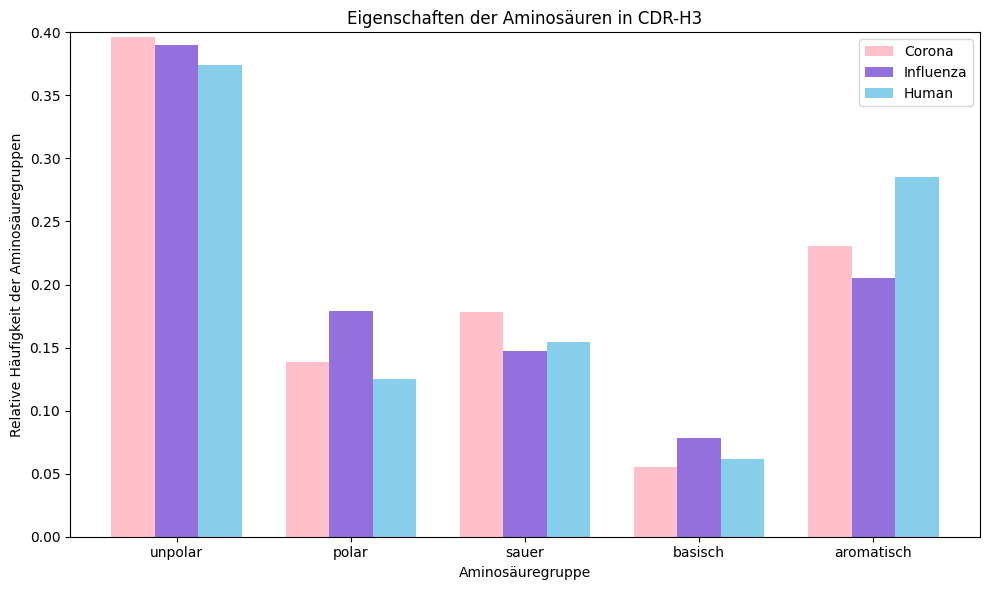

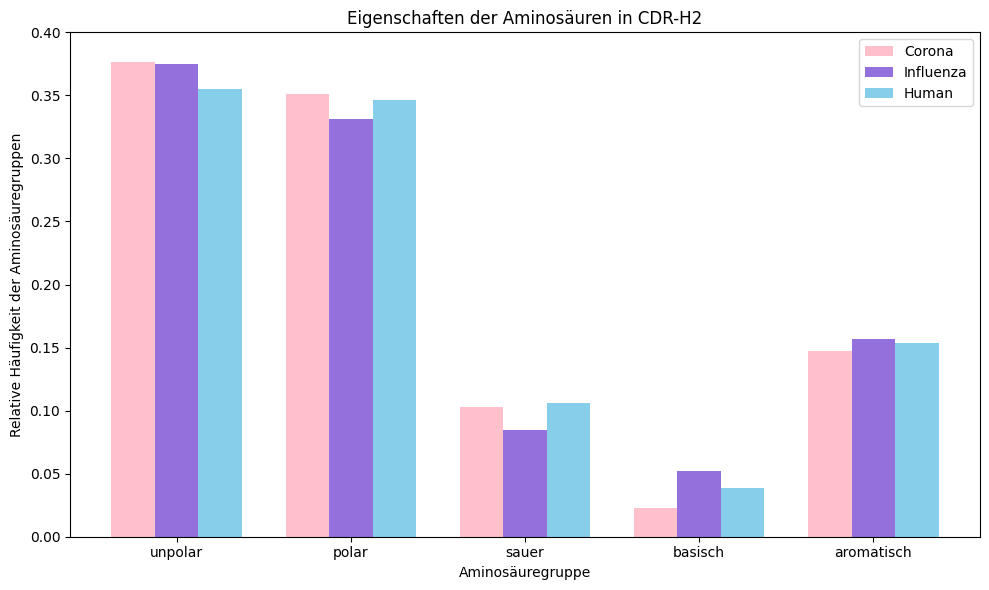

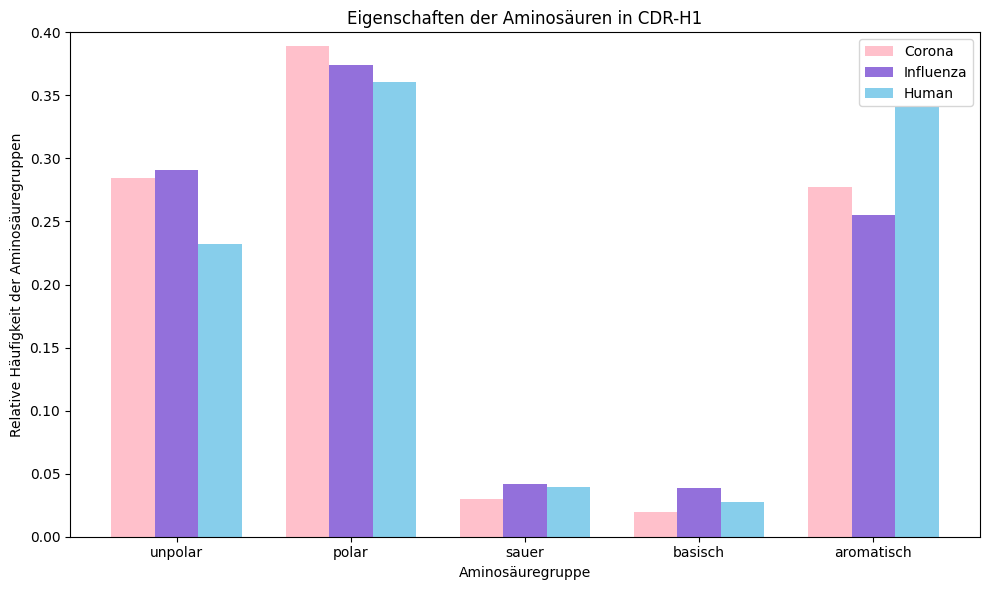

In [ ]:
plot_property_groups(aac_sars_h3, aac_influenza_h3, aac_human_h3, region_label="CDR-H3")
plot_property_groups(aac_sars_h2, aac_influenza_h2, aac_human_h2, region_label="CDR-H2")
plot_property_groups(aac_sars_h1, aac_influenza_h1, aac_human_h1, region_label="CDR-H1")


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the combined dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Loop over all CDR regions
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f"\n Generating heatmap for {cdr}...")
    
    # Find columns that count amino acids for this CDR
    aa_columns = [col for col in df.columns if col.startswith(f"{cdr}_count_")]
    
    if not aa_columns:
        print(f" No count columns found for {cdr}")
        continue

    # Group by source and calculate the mean
    heatmap_data = df.groupby("source")[aa_columns].mean()

    # Sort columns alphabetically
    heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

    # Plot the heatmap
    plt.figure(figsize=(12, 4))
    sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar_kws={"label": "Average Frequency"})
    plt.title(f"Amino Acid Composition in {cdr}")
    plt.xlabel("Amino Acid")
    plt.ylabel("Source")
    plt.tight_layout()
    plt.show()



 Generating bar plot for CDR_H1...


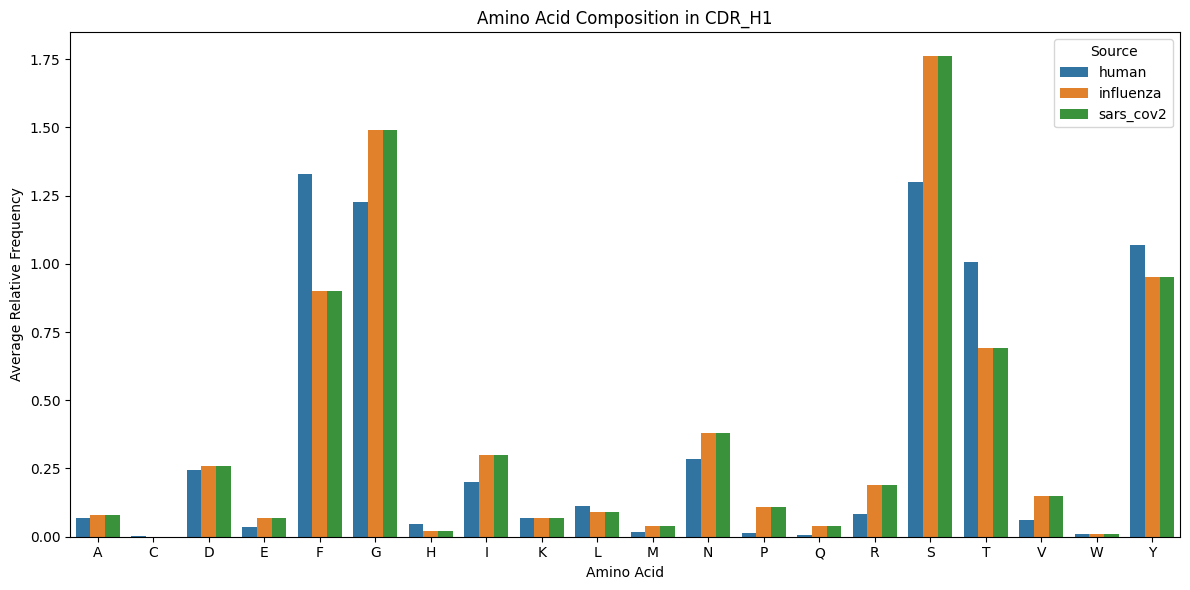


 Generating bar plot for CDR_H2...


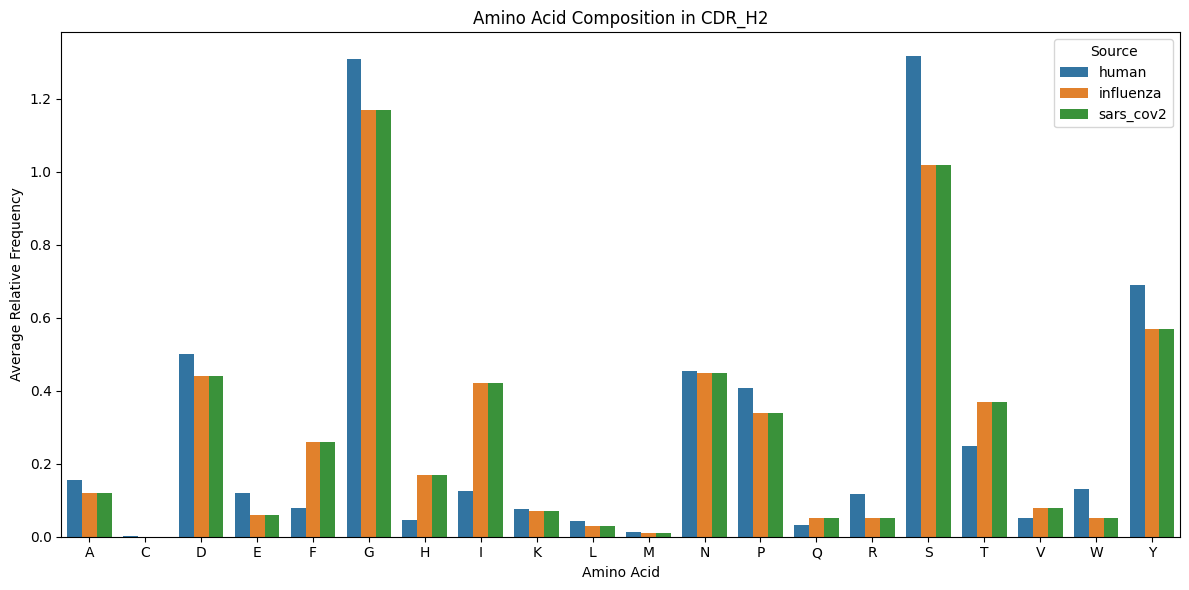


 Generating bar plot for CDR_H3...


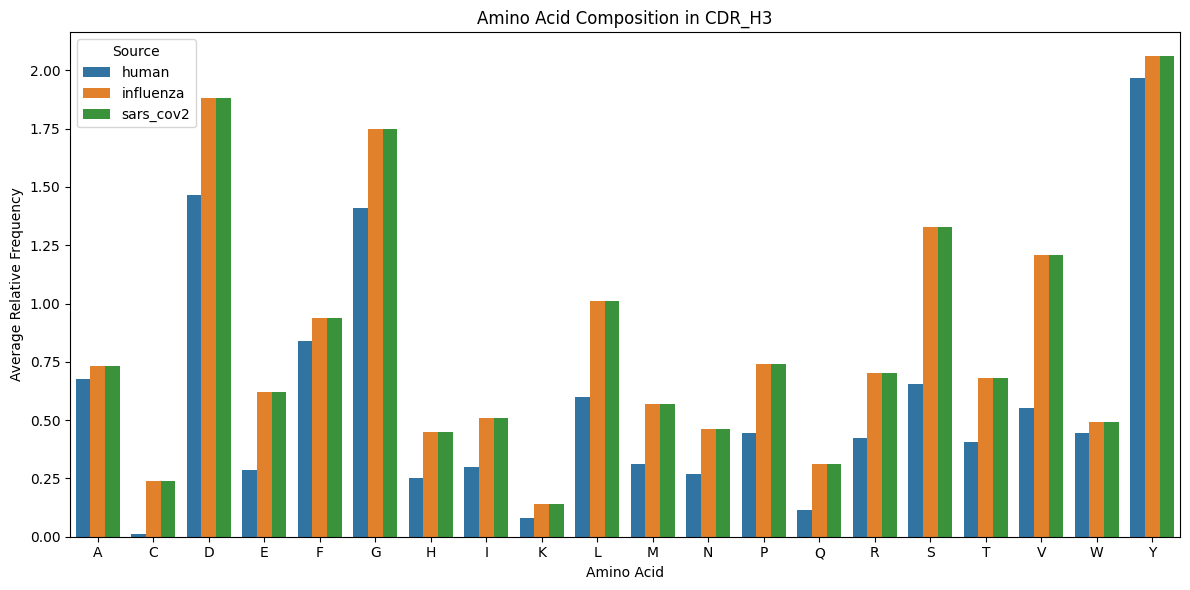

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the combined dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Aminosäure-Reihenfolge (optional schön alphabetisch oder standardisiert)
aa_order = list("ACDEFGHIKLMNPQRSTVWY")

# Loop über CDRs
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f"\n Generating bar plot for {cdr}...")

    # Die Spalten mit Aminosäureanteilen finden
    aa_columns = [col for col in df.columns if col.startswith(f"{cdr}_count_")]

    if not aa_columns:
        print(f" No count columns found for {cdr}")
        continue

    # Gruppieren nach Quelle und Mittelwert berechnen
    grouped = df.groupby("source")[aa_columns].mean()

    # In Long-Format bringen für Seaborn
    df_long = grouped.reset_index().melt(id_vars="source", var_name="AminoAcid", value_name="Frequency")

    # Nur den Aminosäure-Buchstaben extrahieren (z. B. aus 'CDR_H1_count_G' → 'G')
    df_long["AminoAcid"] = df_long["AminoAcid"].str.extract(f"{cdr}_count_(.)")

    # Sortiere nach definierter Aminosäure-Reihenfolge
    df_long["AminoAcid"] = pd.Categorical(df_long["AminoAcid"], categories=aa_order, ordered=True)
    df_long = df_long.sort_values("AminoAcid")

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_long, x="AminoAcid", y="Frequency", hue="source")
    plt.title(f"Amino Acid Composition in {cdr}")
    plt.xlabel("Amino Acid")
    plt.ylabel("Average Relative Frequency")
    plt.legend(title="Source")
    plt.tight_layout()
    plt.show()



 Generating bar plot for CDR_H1...


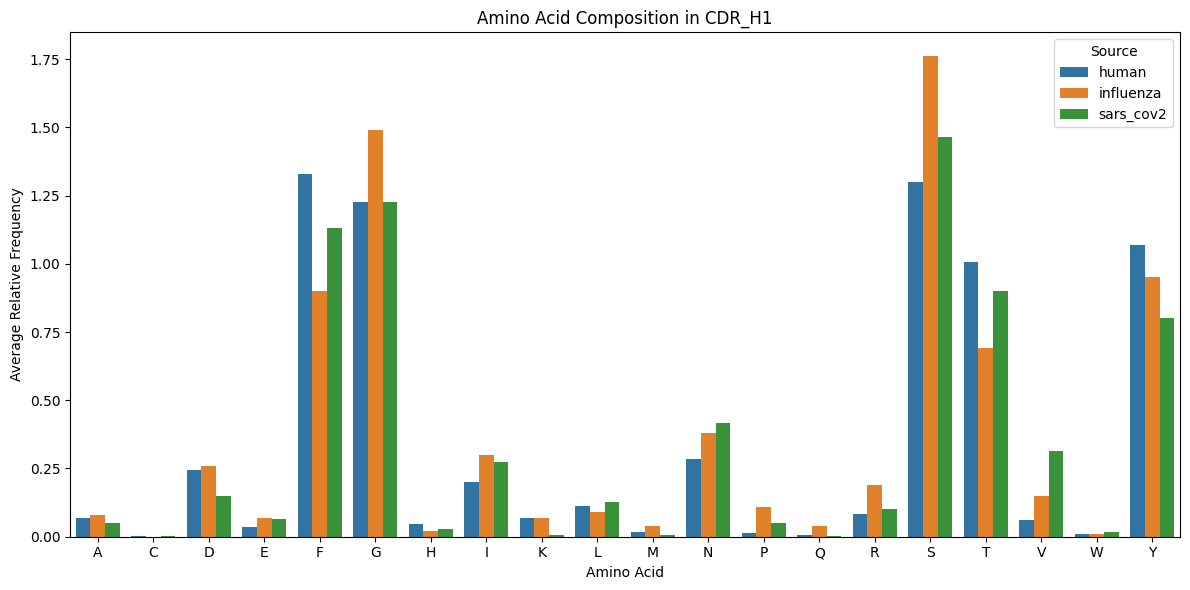


 Generating bar plot for CDR_H2...


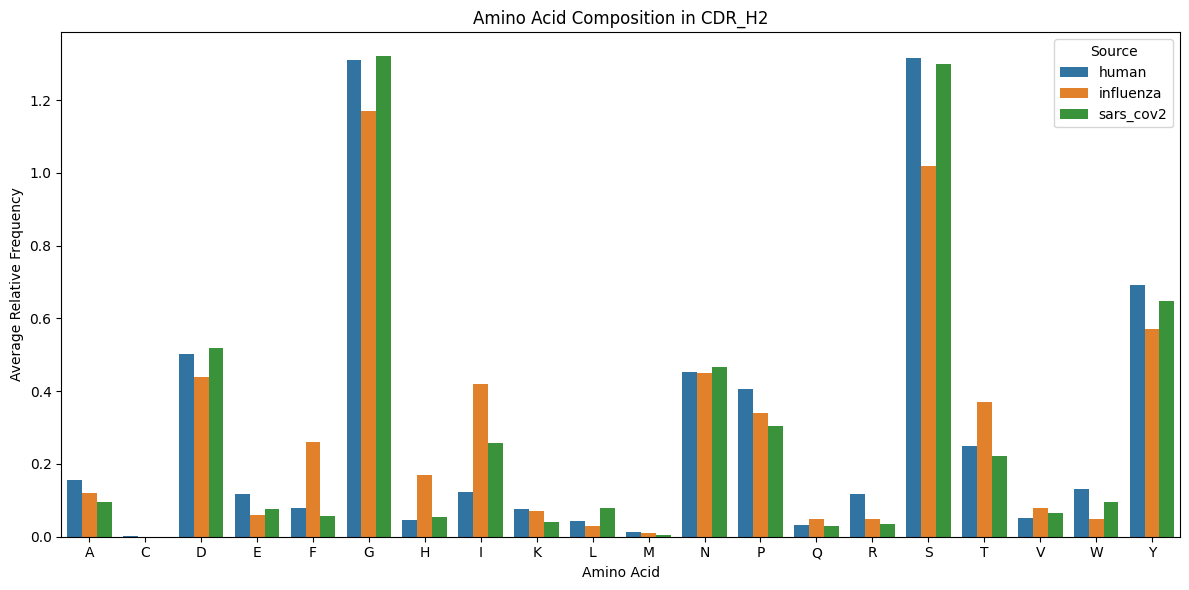


 Generating bar plot for CDR_H3...


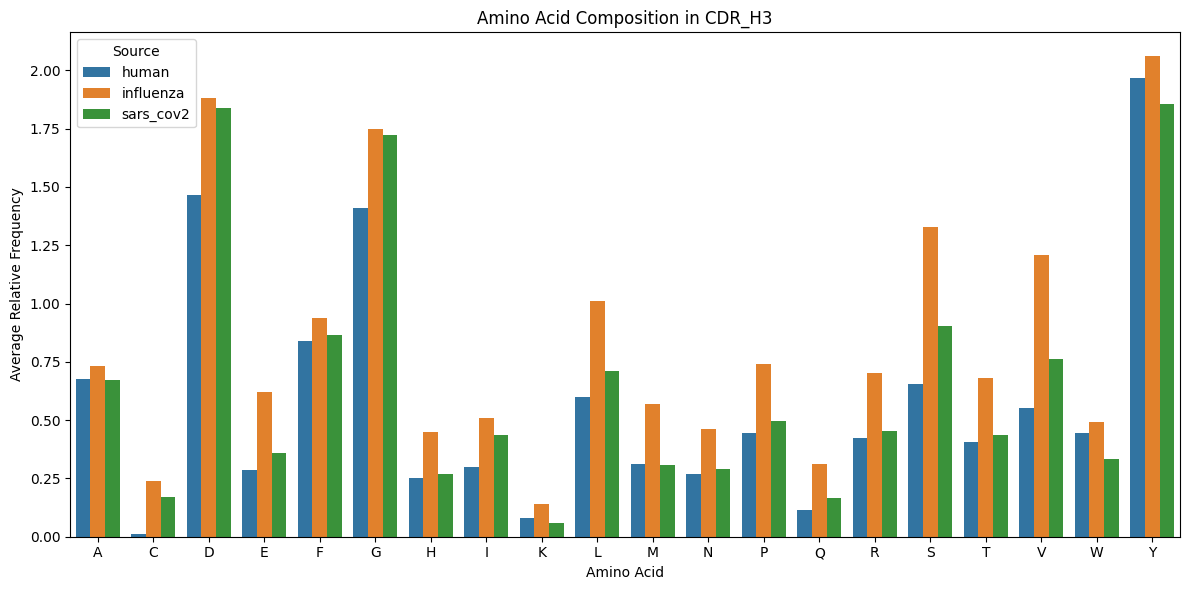

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the combined dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Aminosäure-Reihenfolge (optional schön alphabetisch oder standardisiert)
aa_order = list("ACDEFGHIKLMNPQRSTVWY")

# Loop über CDRs
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f"\n Generating bar plot for {cdr}...")

    # Die Spalten mit Aminosäureanteilen finden
    aa_columns = [col for col in df.columns if col.startswith(f"{cdr}_count_")]

    if not aa_columns:
        print(f" No count columns found for {cdr}")
        continue

    # Gruppieren nach Quelle und Mittelwert berechnen
    grouped = df.groupby("source")[aa_columns].mean()

    # In Long-Format bringen für Seaborn
    df_long = grouped.reset_index().melt(id_vars="source", var_name="AminoAcid", value_name="Frequency")

    # Nur den Aminosäure-Buchstaben extrahieren (z. B. aus 'CDR_H1_count_G' → 'G')
    df_long["AminoAcid"] = df_long["AminoAcid"].str.extract(f"{cdr}_count_(.)")

    # Sortiere nach definierter Aminosäure-Reihenfolge
    df_long["AminoAcid"] = pd.Categorical(df_long["AminoAcid"], categories=aa_order, ordered=True)
    df_long = df_long.sort_values("AminoAcid")

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_long, x="AminoAcid", y="Frequency", hue="source")
    plt.title(f"Amino Acid Composition in {cdr}")
    plt.xlabel("Amino Acid")
    plt.ylabel("Average Relative Frequency")
    plt.legend(title="Source")
    plt.tight_layout()
    plt.show()
